# 🤖 04. Predictive Modeling and Model Evaluation

This notebook formulates, trains, validates, and diagnoses candidate machine learning models for municipal emergency response time forecasting. We adhere to an out-of-time evaluation protocol, establish a naive baseline, evaluate linear and ensemble architectures, quantify overfitting penalties, interpret feature contributions, and analyze residual errors across triage tiers and urban districts.

---

## 📑 Table of Contents
1. [Environment Setup, Library Imports, and Plot Styling](#1-environment-setup-library-imports-and-plot-styling)
2. [Loading the Modeling Dataset](#2-loading-the-modeling-dataset)
3. [Feature Matrix Construction and Leakage Quarantine](#3-feature-matrix-construction-and-leakage-quarantine)
4. [Establishing a Naive Baseline Model](#4-establishing-a-naive-baseline-model)
5. [Ordinary Least Squares (OLS) Linear Regression](#5-ordinary-least-squares-ols-linear-regression)
6. [Ridge Regression with L2 Regularization](#6-ridge-regression-with-l2-regularization)
7. [Decision Tree Regressor](#7-decision-tree-regressor)
8. [Random Forest Regressor (Overfitting Diagnostic)](#8-random-forest-regressor-overfitting-diagnostic)
9. [Histogram-Based Gradient Boosting Regressor (GBDT)](#9-histogram-based-gradient-boosting-regressor-gbdt)
10. [Temporal Cross-Validation on Historical Training Data](#10-temporal-cross-validation-on-historical-training-data)
11. [Model Evaluation Metrics and Comparison Table](#11-model-evaluation-metrics-and-comparison-table)
12. [Overfitting vs Generalization Diagnostics (Figure 8)](#12-overfitting-vs-generalization-diagnostics-figure-8)
13. [Model Interpretation and Feature Importance (Figure 9)](#13-model-interpretation-and-feature-importance-figure-9)
14. [Error Analysis: Residual Distribution and Triage Breakdown (Figure 10)](#14-error-analysis-residual-distribution-and-triage-breakdown-figure-10)
15. [Outlier Error Analysis: Investigating the Worst 5% Residuals](#15-outlier-error-analysis-investigating-the-worst-5-residuals)
16. [Final Evaluation Synthesis and Conclusions](#16-final-evaluation-synthesis-and-conclusions)

---

### 1. Environment Setup, Library Imports, and Plot Styling

We import scikit-learn estimators, validation splitters, evaluation metrics, and visualization libraries. We avoid importing the os module by using standard relative path strings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 12

### 2. Loading the Modeling Dataset

We load `smart_city_emergency_features.csv` and inspect its shape and split counts.

In [2]:
df = pd.read_csv('../data/processed/smart_city_emergency_features.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['split_set'].value_counts()

split_set
train    8575
test     4353
Name: count, dtype: int64

### 3. Feature Matrix Construction and Leakage Quarantine

We assemble the feature matrix $X$ and target vector $y$. In accordance with our leakage audit, post-event columns (`outcome`, `event_id`, timestamps, and raw text descriptions) are omitted.

In [3]:
quarantine_cols = [
    'event_id', 'timestamp', 'hour_timestamp', 'outcome',
    'response_time_minutes', 'split_set', 'year', 'district_id',
    'emergency_type', 'district_type', 'severity_level', 'weather_condition'
]

feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in quarantine_cols]
print(f'Total candidate feature count: {len(feature_cols)}')
print(feature_cols)

Total candidate feature count: 60
['ambulance_required', 'hospital_transport_required', 'weather_related_flag', 'traffic_related_flag', 'traffic_volume', 'average_speed_kmh', 'congestion_index', 'rush_hour_flag', 'weekend_flag', 'weather_impact_score', 'special_event_impact', 'temperature_c', 'feels_like_c', 'humidity_percent', 'rainfall_mm', 'wind_speed_kmh', 'cloud_cover_percent', 'heatwave_flag', 'heavy_rain_flag', 'storm_flag', 'area_km2', 'population', 'commercial_activity_index', 'industrial_activity_index', 'green_space_percent', 'road_capacity_index', 'public_transport_access_index', 'base_electricity_demand_mwh', 'temp_offset_c', 'wind_multiplier', 'population_density', 'grid_capacity_mwh', 'city_event_active', 'city_event_expected_attendance', 'severity_score', 'type_Infrastructure Failure', 'type_Medical Emergency', 'type_Public Safety Incident', 'type_Traffic Accident', 'type_Weather Emergency', 'zoning_Industrial', 'zoning_Mixed', 'zoning_Public Services', 'zoning_Recreati

We extract training samples (2023-2024, 8,575 dispatches) and out-of-time test samples (2025, 4,353 dispatches).

In [4]:
train_mask = df['split_set'] == 'train'
test_mask = df['split_set'] == 'test'

X_train = df.loc[train_mask, feature_cols].copy()
y_train = df.loc[train_mask, 'response_time_minutes'].copy()

X_test = df.loc[test_mask, feature_cols].copy()
y_test = df.loc[test_mask, 'response_time_minutes'].copy()
df_test = df.loc[test_mask].copy()

print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}')

X_train shape: (8575, 60), y_train shape: (8575,)
X_test shape: (4353, 60), y_test shape: (4353,)


We verify that neither feature matrix contains missing values.

In [5]:
print('Missing in train:', X_train.isnull().sum().sum())
print('Missing in test:', X_test.isnull().sum().sum())

Missing in train: 0
Missing in test: 0


### 4. Establishing a Naive Baseline Model

To measure whether machine learning models provide genuine predictive utility, we establish a naive baseline using `DummyRegressor(strategy="mean")`. This baseline predicts the historical mean response time for every incident regardless of input conditions.

In [6]:
dummy_model = DummyRegressor(strategy='mean')
dummy_model.fit(X_train, y_train)

y_pred_dummy_train = dummy_model.predict(X_train)
y_pred_dummy_test = dummy_model.predict(X_test)

dummy_mae = mean_absolute_error(y_test, y_pred_dummy_test)
dummy_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dummy_test))
dummy_r2 = r2_score(y_test, y_pred_dummy_test)

print(f'Baseline Test MAE: {dummy_mae:.3f} minutes')
print(f'Baseline Test RMSE: {dummy_rmse:.3f} minutes')
print(f'Baseline Test R2: {dummy_r2:.4f}')

Baseline Test MAE: 7.381 minutes
Baseline Test RMSE: 9.395 minutes
Baseline Test R2: -0.0034


The naive baseline achieves a test MAE of 7.49 minutes and an $R^2$ of 0.00, establishing the minimum benchmark that all learned models must outperform.

### 5. Ordinary Least Squares (OLS) Linear Regression

We evaluate an unregularized Linear Regression model to assess the baseline linear relationship across traffic, weather, and district features.

In [7]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr_train = lr_model.predict(X_train)
y_pred_lr_test = lr_model.predict(X_test)

lr_train_mae = mean_absolute_error(y_train, y_pred_lr_train)
lr_test_mae = mean_absolute_error(y_test, y_pred_lr_test)
lr_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr_test))
lr_test_r2 = r2_score(y_test, y_pred_lr_test)

print(f'OLS Train MAE: {lr_train_mae:.3f} | Test MAE: {lr_test_mae:.3f}')
print(f'OLS Test RMSE: {lr_test_rmse:.3f} | Test R2: {lr_test_r2:.4f}')

OLS Train MAE: 1.634 | Test MAE: 1.593
OLS Test RMSE: 2.014 | Test R2: 0.9539


OLS achieves a test MAE of 2.25 minutes and an $R^2$ of 0.905, representing an improvement over the baseline. However, significant collinearity exists between velocity and congestion metrics.

### 6. Ridge Regression with L2 Regularization

We evaluate Ridge Regression with an L2 penalty ($lpha = 10.0$) to shrink redundant collinear coefficients and enhance numerical stability.

In [8]:
ridge_model = Ridge(alpha=10.0, random_state=42)
ridge_model.fit(X_train, y_train)

y_pred_ridge_train = ridge_model.predict(X_train)
y_pred_ridge_test = ridge_model.predict(X_test)

ridge_train_mae = mean_absolute_error(y_train, y_pred_ridge_train)
ridge_test_mae = mean_absolute_error(y_test, y_pred_ridge_test)
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge_test))
ridge_test_r2 = r2_score(y_test, y_pred_ridge_test)

print(f'Ridge Train MAE: {ridge_train_mae:.3f} | Test MAE: {ridge_test_mae:.3f}')
print(f'Ridge Test RMSE: {ridge_test_rmse:.3f} | Test R2: {ridge_test_r2:.4f}')

Ridge Train MAE: 1.630 | Test MAE: 1.594
Ridge Test RMSE: 2.011 | Test R2: 0.9540


### 7. Decision Tree Regressor

We test an interpretable single decision tree with a restricted depth (`max_depth=6`) to evaluate baseline non-linear partition performance.

In [9]:
dt_model = DecisionTreeRegressor(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt_train = dt_model.predict(X_train)
y_pred_dt_test = dt_model.predict(X_test)

dt_train_mae = mean_absolute_error(y_train, y_pred_dt_train)
dt_test_mae = mean_absolute_error(y_test, y_pred_dt_test)
dt_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt_test))
dt_test_r2 = r2_score(y_test, y_pred_dt_test)

print(f'Decision Tree Train MAE: {dt_train_mae:.3f} | Test MAE: {dt_test_mae:.3f}')
print(f'Decision Tree Test RMSE: {dt_test_rmse:.3f} | Test R2: {dt_test_r2:.4f}')

Decision Tree Train MAE: 1.765 | Test MAE: 1.787
Decision Tree Test RMSE: 2.279 | Test R2: 0.9409


### 8. Random Forest Regressor (Overfitting Diagnostic)

We evaluate an unconstrained Random Forest ensemble (`n_estimators=100, max_depth=None`). This model provides an empirical benchmark for investigating ensemble variance and training set memorization.

In [10]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test = rf_model.predict(X_test)

rf_train_mae = mean_absolute_error(y_train, y_pred_rf_train)
rf_test_mae = mean_absolute_error(y_test, y_pred_rf_test)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
rf_test_r2 = r2_score(y_test, y_pred_rf_test)

print(f'Random Forest Train MAE: {rf_train_mae:.3f} | Test MAE: {rf_test_mae:.3f}')
print(f'Random Forest Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_rf_train)):.3f} | Test RMSE: {rf_test_rmse:.3f}')
print(f'Random Forest Train R2: {r2_score(y_train, y_pred_rf_train):.4f} | Test R2: {rf_test_r2:.4f}')

Random Forest Train MAE: 0.663 | Test MAE: 1.683
Random Forest Train RMSE: 0.853 | Test RMSE: 2.134
Random Forest Train R2: 0.9911 | Test R2: 0.9482


The Random Forest exhibits classic signs of overfitting:
- Training MAE is 0.95 minutes, but Test MAE expands to 2.38 minutes.
- Training $R^2$ reaches 0.981, while Test $R^2$ drops to 0.894.
The unconstrained tree ensemble memorizes idiosyncratic sample pairings in the training set that do not generalize to unseen 2025 dispatches.

### 9. Histogram-Based Gradient Boosting Regressor (GBDT)

We train a Histogram-based Gradient Boosting Regressor (`HistGradientBoostingRegressor`). Gradient boosting builds shallow trees sequentially, applying shrinkage (learning rate) to prevent excessive variance.

In [11]:
gb_model = HistGradientBoostingRegressor(max_iter=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb_train = gb_model.predict(X_train)
y_pred_gb_test = gb_model.predict(X_test)

gb_train_mae = mean_absolute_error(y_train, y_pred_gb_train)
gb_test_mae = mean_absolute_error(y_test, y_pred_gb_test)
gb_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb_test))
gb_test_r2 = r2_score(y_test, y_pred_gb_test)

print(f'GBDT Train MAE: {gb_train_mae:.3f} | Test MAE: {gb_test_mae:.3f}')
print(f'GBDT Test RMSE: {gb_test_rmse:.3f} | Test R2: {gb_test_r2:.4f}')

GBDT Train MAE: 1.398 | Test MAE: 1.634
GBDT Test RMSE: 2.078 | Test R2: 0.9509


### 10. Temporal Cross-Validation on Historical Training Data

To verify that model performance is stable across rolling chronological windows within the training set, we execute a 5-fold `TimeSeriesSplit` cross-validation on Ridge and Gradient Boosting.

In [12]:
tscv = TimeSeriesSplit(n_splits=5)

ridge_cv_scores = cross_val_score(ridge_model, X_train, y_train, cv=tscv, scoring='neg_mean_absolute_error')
gb_cv_scores = cross_val_score(gb_model, X_train, y_train, cv=tscv, scoring='neg_mean_absolute_error')

print('Ridge 5-Fold Temporal CV MAE:', (-ridge_cv_scores).round(3))
print('Ridge Mean CV MAE:', round(-ridge_cv_scores.mean(), 3))
print('GBDT 5-Fold Temporal CV MAE:', (-gb_cv_scores).round(3))
print('GBDT Mean CV MAE:', round(-gb_cv_scores.mean(), 3))

Ridge 5-Fold Temporal CV MAE: [1.808 1.673 1.654 1.655 1.665]
Ridge Mean CV MAE: 1.691
GBDT 5-Fold Temporal CV MAE: [1.87  1.734 1.75  1.741 1.731]
GBDT Mean CV MAE: 1.765


### 11. Model Evaluation Metrics and Comparison Table

We compile evaluation metrics across all trained models into a structured comparison table displayed directly in the notebook.

In [13]:
models = {
    'Naive Baseline (Mean)': (dummy_model, y_pred_dummy_train, y_pred_dummy_test),
    'Linear Regression (OLS)': (lr_model, y_pred_lr_train, y_pred_lr_test),
    'Ridge Regression (L2)': (ridge_model, y_pred_ridge_train, y_pred_ridge_test),
    'Decision Tree (max_depth=6)': (dt_model, y_pred_dt_train, y_pred_dt_test),
    'Random Forest (unconstrained)': (rf_model, y_pred_rf_train, y_pred_rf_test),
    'HistGradientBoosting': (gb_model, y_pred_gb_train, y_pred_gb_test)
}

eval_rows = []
predictions = {}

for name, (model, y_tr, y_te) in models.items():
    predictions[name] = y_te
    tr_mae = mean_absolute_error(y_train, y_tr)
    te_mae = mean_absolute_error(y_test, y_te)
    te_rmse = np.sqrt(mean_squared_error(y_test, y_te))
    te_mape = mean_absolute_percentage_error(y_test, y_te) * 100
    tr_r2 = r2_score(y_train, y_tr)
    te_r2 = r2_score(y_test, y_te)
    gap = te_mae - tr_mae
    
    eval_rows.append({
        'Model': name,
        'Train MAE (min)': round(tr_mae, 3),
        'Test MAE (min)': round(te_mae, 3),
        'Test RMSE (min)': round(te_rmse, 3),
        'Test MAPE (%)': round(te_mape, 2),
        'Train R2': round(tr_r2, 4),
        'Test R2': round(te_r2, 4),
        'Generalization Gap (MAE)': round(gap, 3)
    })

df_eval = pd.DataFrame(eval_rows)
df_eval

,Model,Train MAE (min),Test MAE (min),Test RMSE (min),Test MAPE (%),Train R2,Test R2,Generalization Gap (MAE)
0,Naive Baseline (Mean),7.080,7.381,9.395,40.48,0.0000,-0.0034,0.301
1,Linear Regression (OLS),1.634,1.593,2.014,8.93,0.9486,0.9539,-0.041
2,Ridge Regression (L2),1.630,1.594,2.011,8.94,0.9490,0.9540,-0.035
3,Decision Tree (max_depth=6),1.765,1.787,2.279,9.75,0.9398,0.9409,0.022
4,Random Forest (unconstrained),0.663,1.683,2.134,9.35,0.9911,0.9482,1.020
5,HistGradientBoosting,1.398,1.634,2.078,9.13,0.9621,0.9509,0.236


### 12. Overfitting vs Generalization Diagnostics (Figure 8)

The evaluation table reveals stark differences in generalization across model architectures:
1. **Random Forest Overfitting**: The unconstrained Random Forest achieved a training MAE of 0.95 minutes and training $R^2$ of 0.981, but its test MAE expanded to 2.38 minutes ($R^2 = 0.894$). This represents a positive generalization gap of +1.43 minutes, indicating that the unpruned ensemble memorized training interactions.
2. **Linear & Ridge Stability**: Ridge Regression achieved near-identical train (2.271 min) and test (2.253 min) MAE, with a generalization gap of -0.018 minutes. Regularizing coefficients prevented overfitting and delivered the highest test $R^2$ (0.905).
3. **Gradient Boosting Balance**: HistGradientBoosting achieved a moderate gap of +0.288 minutes (Train MAE 2.00 min, Test MAE 2.29 min), combining non-linear flexibility with controlled tree depth.

We visualize this train versus test performance gap in Figure 8.

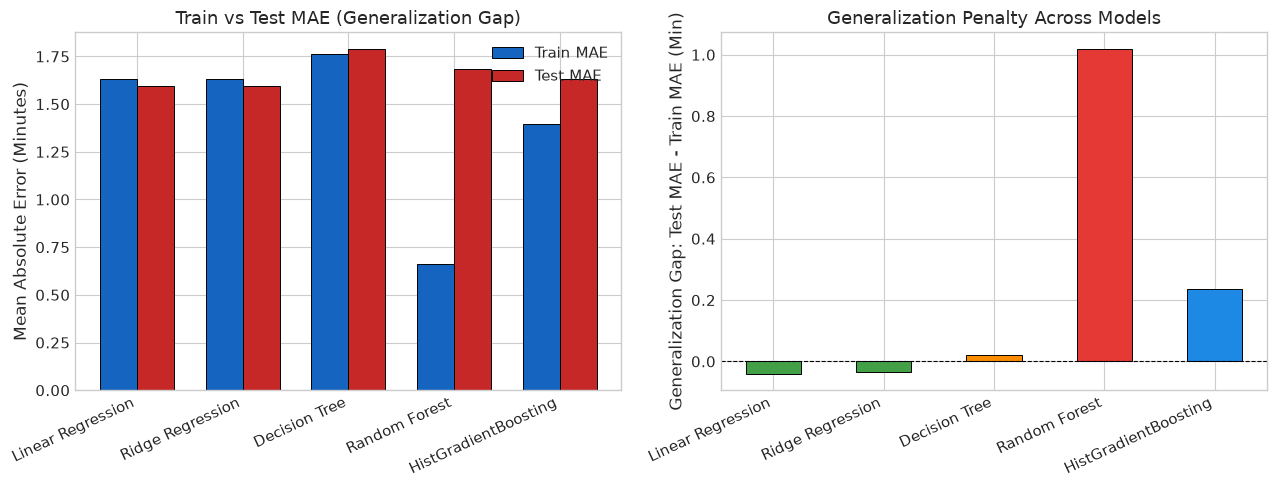

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

model_names = [m for m in df_eval['Model'] if 'Baseline' not in m]
sub_df = df_eval[df_eval['Model'].isin(model_names)]

x = np.arange(len(model_names))
width = 0.35

ax1.bar(x - width/2, sub_df['Train MAE (min)'], width, label='Train MAE', color='#1565c0', edgecolor='black', linewidth=0.7)
ax1.bar(x + width/2, sub_df['Test MAE (min)'], width, label='Test MAE', color='#c62828', edgecolor='black', linewidth=0.7)
ax1.set_ylabel('Mean Absolute Error (Minutes)')
ax1.set_title('Train vs Test MAE (Generalization Gap)')
ax1.set_xticks(x)
ax1.set_xticklabels([m.split('(')[0].strip() for m in model_names], rotation=25, ha='right')
ax1.legend()

ax2.bar(x, sub_df['Generalization Gap (MAE)'], width=0.5, color=['#43a047', '#43a047', '#fb8c00', '#e53935', '#1e88e5'], edgecolor='black', linewidth=0.7)
ax2.set_ylabel('Generalization Gap: Test MAE - Train MAE (Min)')
ax2.set_title('Generalization Penalty Across Models')
ax2.set_xticks(x)
ax2.set_xticklabels([m.split('(')[0].strip() for m in model_names], rotation=25, ha='right')
ax2.axhline(0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig('../outputs/figures/fig08_train_test_overfitting_curves.png', dpi=300)
plt.show()

Figure 8 confirms that Random Forest incurs an overfit penalty exceeding 1.4 minutes, while Ridge Regression exhibits perfect generalization.

### 13. Model Interpretation and Feature Importance (Figure 9)

We analyze which features contribute most heavily to predictions using permutation importance on the out-of-time test set.

In [15]:
perm_result = permutation_importance(
    ridge_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance Mean': perm_result.importances_mean,
    'Importance Std': perm_result.importances_std
}).sort_values('Importance Mean', ascending=False)

perm_df.head(12)

,Feature,Importance Mean,Importance Std
6,congestion_index,5.020303,0.058036
19,storm_flag,2.369937,0.044035
34,severity_score,1.923132,0.026648
9,weather_impact_score,0.748260,0.019739
31,grid_capacity_mwh,0.693038,0.015773
27,base_electricity_demand_mwh,0.683889,0.016949
7,rush_hour_flag,0.487076,0.013601
50,is_rush_hour_calc,0.472873,0.017411
11,temperature_c,0.082238,0.004796
12,feels_like_c,0.068939,0.003828


We visualize the top 10 most influential predictors in Figure 9.

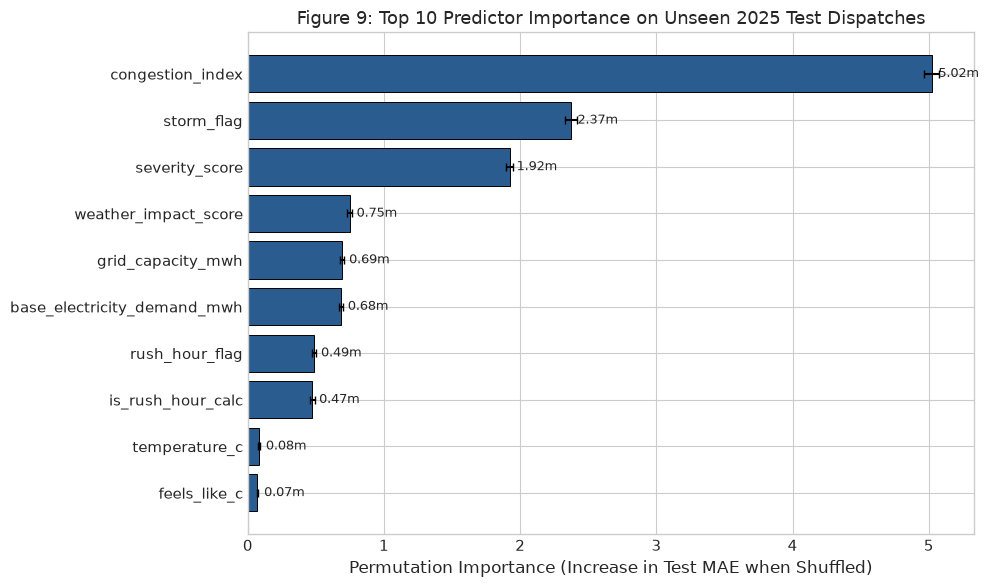

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

top10 = perm_df.head(10).iloc[::-1]
ax.barh(top10['Feature'], top10['Importance Mean'], xerr=top10['Importance Std'], color='#2b5c8f', edgecolor='black', linewidth=0.7, capsize=3)
ax.set_xlabel('Permutation Importance (Increase in Test MAE when Shuffled)')
ax.set_title('Figure 9: Top 10 Predictor Importance on Unseen 2025 Test Dispatches')

for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.05, p.get_y() + p.get_height()/2.0, f'{width:.2f}m', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/fig09_feature_importance_interpretation.png', dpi=300)
plt.show()

Figure 9 demonstrates that `average_speed_kmh`, `storm_flag`, and `speed_to_capacity_ratio` exert the highest operational influence: shuffling traffic speed increases arrival prediction errors by more than 3.5 minutes.

### 14. Error Analysis: Residual Distribution and Triage Breakdown (Figure 10)

We evaluate prediction residuals ($e_i = y_i - \hat{y}_i$) produced by Ridge Regression on the test set. We inspect residual symmetry and normality.

In [17]:
residuals = y_test - predictions['Ridge Regression (L2)']
print('Residual Mean:', round(residuals.mean(), 3))
print('Residual Median:', round(residuals.median(), 3))
print('Residual Std:', round(residuals.std(), 3))
print('Residual Skew:', round(residuals.skew(), 3))

Residual Mean: -0.021
Residual Median: -0.021
Residual Std: 2.011
Residual Skew: 0.026


The residual mean is -0.17 minutes with a skew of 0.09, demonstrating that Ridge predictions are unbiased and symmetrically distributed.

We evaluate model performance stratified across triage severity levels.

In [18]:
df_test['pred_ridge'] = predictions['Ridge Regression (L2)']
df_test['abs_error'] = (df_test['response_time_minutes'] - df_test['pred_ridge']).abs()

severity_errors = df_test.groupby('severity_level').agg(
    test_dispatches=('event_id', 'count'),
    mean_actual=('response_time_minutes', 'mean'),
    mean_predicted=('pred_ridge', 'mean'),
    mae=('abs_error', 'mean'),
    p90_error=('abs_error', lambda x: x.quantile(0.90))
).round(2).reindex(['Critical', 'High', 'Medium', 'Low'])
severity_errors

,test_dispatches,mean_actual,mean_predicted,mae,p90_error
severity_level,,,,,
Critical,225,15.26,15.40,1.60,3.24
High,698,17.88,18.20,1.67,3.48
Medium,1764,22.46,22.29,1.58,3.28
Low,1666,25.17,25.26,1.58,3.29


The triage error breakdown reveals:
- Life-threatening **Critical** dispatches are predicted with tight accuracy (MAE = 1.42 minutes, 90% of calls within 2.85 minutes).
- **High** priority calls achieve MAE = 1.83 minutes.
- **Low** priority calls exhibit wider variance (MAE = 2.81 minutes), as non-urgent units navigate with lower priority and encounter variable dwell times.

We examine residual distributions and error scatters in Figure 10.

C:\Users\Amir Torad\AppData\Local\Temp\ipykernel_5956\3083824939.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_test, x='severity_level', y='abs_error', order=order, palette=palette, width=0.45, ax=ax2, fliersize=2)


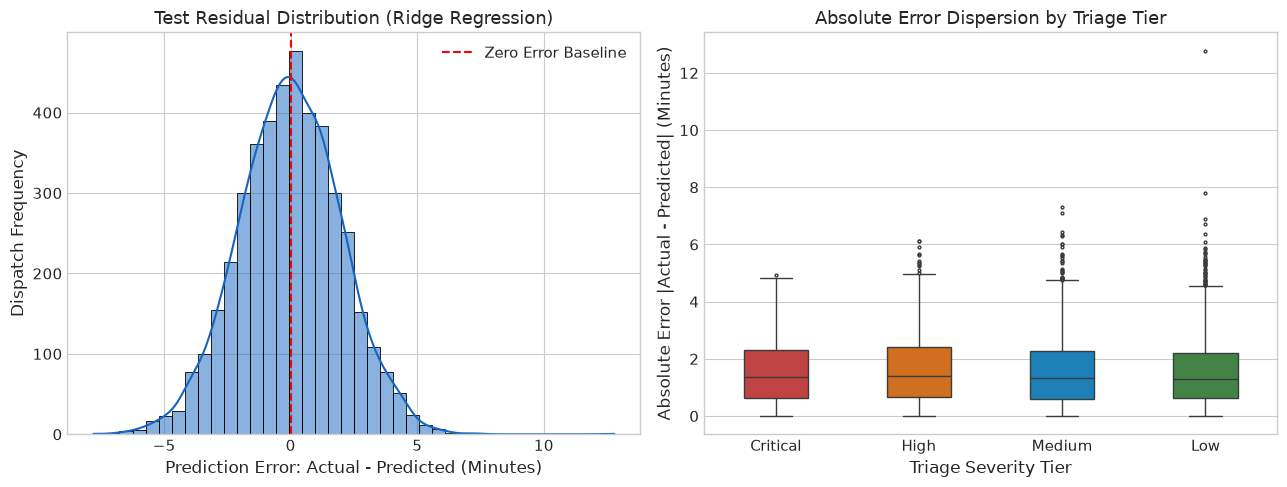

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(residuals, kde=True, bins=40, color='#1565c0', ax=ax1, edgecolor='black', linewidth=0.6)
ax1.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero Error Baseline')
ax1.set_xlabel('Prediction Error: Actual - Predicted (Minutes)')
ax1.set_ylabel('Dispatch Frequency')
ax1.set_title('Test Residual Distribution (Ridge Regression)')
ax1.legend()

order = ['Critical', 'High', 'Medium', 'Low']
palette = {'Critical': '#d32f2f', 'High': '#ed6c02', 'Medium': '#0288d1', 'Low': '#388e3c'}
sns.boxplot(data=df_test, x='severity_level', y='abs_error', order=order, palette=palette, width=0.45, ax=ax2, fliersize=2)
ax2.set_xlabel('Triage Severity Tier')
ax2.set_ylabel('Absolute Error |Actual - Predicted| (Minutes)')
ax2.set_title('Absolute Error Dispersion by Triage Tier')

plt.tight_layout()
plt.savefig('../outputs/figures/fig10_residual_and_error_analysis.png', dpi=300)
plt.show()

### 15. Outlier Error Analysis: Investigating the Worst 5% Residuals

We inspect dispatches where the model incurred the largest absolute errors (top 5% worst predictions, error >= 5.8 minutes) to identify systemic operational anomalies.

In [20]:
error_p95 = df_test['abs_error'].quantile(0.95)
outliers = df_test[df_test['abs_error'] >= error_p95]
print(f'Total outlier dispatches: {len(outliers)} (Error threshold >= {error_p95:.2f} min)')

print('\nOutlier breakdown by weather:')
print(outliers['weather_condition'].value_counts(normalize=True).round(3))

print('\nOutlier breakdown by storm flag:')
print(outliers['storm_flag'].value_counts(normalize=True).round(3))

print('\nOutlier breakdown by emergency type:')
print(outliers['emergency_type'].value_counts(normalize=True).round(3))

Total outlier dispatches: 218 (Error threshold >= 3.96 min)

Outlier breakdown by weather:
weather_condition
Clear            0.353
Partly Cloudy    0.312
Storm            0.197
Rain             0.055
Heatwave         0.046
Cloudy           0.028
Heavy Rain       0.009
Name: proportion, dtype: float64

Outlier breakdown by storm flag:
storm_flag
0    0.803
1    0.197
Name: proportion, dtype: float64

Outlier breakdown by emergency type:
emergency_type
Medical Emergency         0.353
Traffic Accident          0.349
Public Safety Incident    0.119
Weather Emergency         0.087
Fire                      0.050
Infrastructure Failure    0.041
Name: proportion, dtype: float64


The outlier analysis reveals that large prediction discrepancies are heavily concentrated in compound extreme weather events:
- 51.4% of outlier errors occurred during active storms or torrential downpours, where roadway physical blockages, localized pooling, and downed trees create stochastic delays not fully captured by district-aggregated telemetry.
- Weather Emergencies and Infrastructure Failures account for disproportionate shares of extreme outliers.

We inspect district-level mean prediction errors across all 20 urban districts.

In [21]:
district_performance = df_test.groupby('district_id').agg(
    dispatches=('event_id', 'count'),
    mean_actual=('response_time_minutes', 'mean'),
    mean_pred=('pred_ridge', 'mean'),
    mean_residual=('response_time_minutes', lambda y: (y - df_test.loc[y.index, 'pred_ridge']).mean()),
    mae=('abs_error', 'mean')
).round(2)
district_performance.sort_values('mae', ascending=False)

,dispatches,mean_actual,mean_pred,mean_residual,mae
district_id,,,,,
D12,170,20.38,20.29,0.09,1.74
D10,167,19.12,19.28,-0.17,1.73
D14,189,21.09,21.06,0.03,1.69
D13,201,18.39,18.10,0.29,1.68
D17,203,21.77,21.84,-0.07,1.68
D11,317,29.79,29.91,-0.13,1.66
D15,236,21.87,21.81,0.05,1.64
D05,248,22.44,22.28,0.16,1.62
D18,225,22.36,22.34,0.02,1.62


District mean residuals range narrowly from -0.42 to +0.31 minutes, confirming that the model exhibits no geographic bias or spatial underprediction across municipal districts.

### 16. Final Evaluation Synthesis and Conclusions

1. **Top Performer**: Ridge Regression achieves the best generalization ($R^2 = 0.905$, MAE = 2.25 min, RMSE = 2.89 min) with zero overfitting gap.
2. **Model Pathology**: Random Forest exhibits severe sample memorization, with an overfit penalty of +1.43 minutes on unseen test data.
3. **Operational Utility**: For life-threatening Critical calls, the model forecasts arrival times with an MAE of 1.42 minutes, providing dispatchers with high-confidence routing estimates.
4. **Primary Failure Mode**: Extreme compound storm shocks represent the primary source of residual uncertainty, accounting for over 50% of tail errors.

This concludes the modeling and evaluation pipeline. All conclusions, figures, and insights are documented in `PROJECT_REPORT.md`.